In [1]:
import torch
from torch import nn, optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, TensorDataset, random_split
import matplotlib.pyplot as plt

/Users/rachid.outbib/miniconda3/envs/intuition/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import utils
import os
import numpy as np
import matplotlib.pyplot as plt
from algorithms import *

In [3]:
hsi,_,_ = utils.load_HSI("./dataset/Samson.mat") # load Samson Dataset
data = hsi.get_spectra() # Get the hyperspectral observation 
A = hsi.get_abundances() # Get the ground truth for the abundances
E = hsi.endmembers # Get the ground truth for the endmembers
n_sources = 3

In [4]:
#Print the image

data_np=np.array(data)

A_np=np.array(A)

E_np=np.array(E)

#concatenate the abundances to the data
data_with_abundances = np.concatenate((data_np, A_np), axis=1)

dataset = TensorDataset(torch.from_numpy(data_with_abundances).float())

batch_size = 32  # Choisis selon ta mémoire disponible

# Taille des ensembles
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

# Séparation aléatoire
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,  # Mélange pour l'entraînement
    num_workers=2,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,  # Pas de mélange pour le test
    num_workers=2,
)




In [5]:
E_np.shape

(3, 156)

In [6]:
#verify if train_loader and test_loader contains NaN values
for data in train_loader:
    if torch.isnan(data[0]).any():
        print("NaN values in train_loader")
        break

# VAE

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Dirichlet

class PositiveLinear(nn.Linear):
    def forward(self, input):
        # Appliquer une contrainte de positivité sur les poids
        self.weight.data = torch.clamp(self.weight.data, min=0)
        return super().forward(input)


In [34]:
import itertools

class VAE(nn.Module):
    def __init__(self, nb_channels, n_sources=3,temp=1.0):
        super(VAE, self).__init__()
        self.n_sources = n_sources
        self.temp = temp

        self.encoder = nn.Sequential(
            nn.Linear(nb_channels, 78),
            nn.BatchNorm1d(78),
            nn.ReLU(),
            nn.Linear(78, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64, 36),
            nn.BatchNorm1d(36),
            nn.ReLU(),
            
        )

        self.alpha_head = nn.Sequential(
            nn.Linear(36, n_sources),
            nn.Softmax(dim=1)
        )
        #couche linéaire
        self.decoder_phi_a = nn.Sequential(
            PositiveLinear(n_sources, 36),
            nn.BatchNorm1d(36),
            nn.ReLU(),
            PositiveLinear(36, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            PositiveLinear(64, 78),
            nn.BatchNorm1d(78),
            nn.ReLU(),
            PositiveLinear(78, nb_channels),
            nn.BatchNorm1d(nb_channels),
            nn.Sigmoid()
        )

        self.M=PositiveLinear(n_sources, nb_channels, bias=False)



        # self.softmax = nn.Softmax(dim=1)  # remove

    def encode(self, x):
        x = self.encoder(x)
        if torch.isnan(x).any():
            raise ValueError("NaNs in encoder backbone")
        return x
    
    def decode(self, z):
        phi_z = self.decoder_phi_a(z)
        Ma=self.M(z)
        phi_z = torch.clamp(phi_z, min=-1, max=1)
        recon= Ma+ phi_z
        return phi_z
    
    def forward(self, x):
        x= torch.tensor(x)
        x=self.encode(x)
        x=x/self.temp
        alpha_values = self.alpha_head(x)
        self.dirich_dist = Dirichlet(alpha_values)
        z = self.dirich_dist.rsample()

        z= torch.clamp(z, min=0, max=1) 
        z= self.decode(z)

        return z,alpha_values
    
def SAD(y_true: torch.Tensor, y_pred: torch.Tensor) -> torch.Tensor:
    # Normalisation L2
    y_true_norm = F.normalize(y_true, p=2, dim=-1)
    y_pred_norm = F.normalize(y_pred, p=2, dim=-1)

    # Produit scalaire normalisé
    cos_theta = torch.sum(y_true_norm * y_pred_norm, dim=-1)

    # Clamp pour stabilité numérique
    cos_theta = torch.clamp(cos_theta, -1.0, 1.0)

    # Angle en radians
    sad = torch.acos(cos_theta)

    # Moyenne sur le batch
    return sad.mean()

def dirichlet_kl_divergence(alpha, beta):
    # Calcul de la divergence KL entre Dir(alpha) et Dir(beta)
    #vérifier si alpha et beta sont des tenseurs de même dimension
    if alpha.shape != beta.shape:
        raise("alpha and beta must have the same shape")

    #clipper les valeurs de alpha et beta pour éviter les NaN
    alpha = torch.clamp(alpha, min=1e-6)
    beta = torch.clamp(beta, min=1e-6)

    alpha_sum= torch.sum(alpha, dim=1, keepdim=True)
    beta_sum= torch.sum(beta, dim=1, keepdim=True)

    term1 = torch.lgamma(alpha_sum) - torch.lgamma(beta_sum)

    term2 = torch.sum(torch.lgamma(beta) - torch.lgamma(alpha), dim=1)

    term3 = torch.sum((alpha - beta) * (torch.digamma(alpha) - torch.digamma(alpha_sum)), dim=1)

    kl_div = term1 + term2 + term3

    kl_div = torch.mean(kl_div)
    return kl_div

def beta_vae_loss(x, x_recon, alpha, alpha_prior):
    
    #mu_k = log(alpha_k) - 1/len(alpha) * sum(log(alpha_i))
    mu= torch.log(alpha) - torch.mean(torch.log(alpha), dim=1, keepdim=True)
    
    #Sigma_k = 1/alpha_k * (1 - 2/len(alpha)) + 1/len(alpha)^2 * sum(1/alpha_i)
    log_var = torch.log(1/alpha * (1 - 2/alpha.shape[1]) + torch.mean(1/alpha, dim=1, keepdim=True)/ (alpha.shape[1]**2))
    
    KLD = -0.5 * torch.mean(1 + log_var - mu.pow(2) - log_var.exp())
    return SAD(x, x_recon), F.mse_loss(x_recon, x, reduction='sum'), KLD

def loss_function(x, x_recon, alpha, alpha_prior, beta=4.0, gamma=1.0,k_sad=1.0,k_mse=2.0,k_dkl=2.0):
    sad_loss, mse_loss, dkl_loss = beta_vae_loss(x, x_recon, alpha, alpha_prior)
    return sad_loss**k_sad + gamma * ((1e-3*mse_loss)**k_mse) + beta *((1e-3* dkl_loss)**k_dkl)

In [9]:
from torch.optim.lr_scheduler import ReduceLROnPlateau,OneCycleLR

In [35]:
vae = VAE(nb_channels=156, n_sources=n_sources,temp=0.1)
optimizer = optim.Adam(vae.parameters(), lr=1e-3)


epochs = 50
outputs = []
losses = []

#scheduler = OneCycleLR(optimizer, max_lr=1e-3, steps_per_epoch=len(train_loader), epochs=epochs)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vae.to(device)

for epoch in range(epochs):
    epoch_outputs = []
    epoch_losses = []
    for element in train_loader:
        #Transformer le tuple en tensor
        element = element[0]
        
        #récupérer les 156 premières colonnes
        pixel = element[:,:156]

        alpha_prior = element[:,156:]

        pixel = pixel.to(device).float()

        alpha_prior = alpha_prior.to(device).float()
        #print("Pixel.shape : ",pixel.shape)
        #verify if pixel contains NaN values

        output, alpha_values = vae(pixel)

        # Squeeze channel dimension to match output shape

        #loss = beta_vae_loss(output, pixel, alpha_values, beta=0)
        #calculer la loss entre output et pixel avec une rsme
        sad, mse, dkl = beta_vae_loss(pixel, output, alpha_values, alpha_prior)
        loss= loss_function(pixel, output, alpha_values, alpha_prior, beta=0.001, gamma=1e-3, k_sad=0.25, k_mse=1.5, k_dkl=2.0)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        #scheduler.step(loss)
        epoch_losses.append(loss.item()/len(pixel))

        epoch_outputs.append((pixel, output))

    losses.append(np.mean(epoch_losses))
    outputs.append(epoch_outputs)

    print(f"Epoch {epoch+1}, Loss: {loss.item()/len(pixel)} (SAD: {sad.item()**0.25}, MSE: {((1e-3*mse.item())**1.5)}, DKL: {(dkl.item()*1e-3)**2.0})")


/var/folders/74/bcmygj1n3yj3djmv4kgqrkch0000gp/T/ipykernel_51447/1000933007.py:62: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x= torch.tensor(x)


Epoch 1, Loss: 0.03912956118583679 (SAD: 0.7817443119110894, MSE: 0.3171982018890242, DKL: 0.5296787851664759)
Epoch 2, Loss: 0.03902716040611267 (SAD: 0.779190448262359, MSE: 0.39802214258503354, DKL: 0.9547610993124395)
Epoch 3, Loss: 0.036924198269844055 (SAD: 0.7381341478949351, MSE: 0.34978839734674827, DKL: 4.957829154184219e-05)
Epoch 4, Loss: 0.03337857127189636 (SAD: 0.667175311257194, MSE: 0.39557094071383475, DKL: 0.0005196361155761552)
Epoch 5, Loss: 0.03291131854057312 (SAD: 0.657770500668021, MSE: 0.4548979437257015, DKL: 0.0009508825670684601)
Epoch 6, Loss: 0.03295771777629852 (SAD: 0.6588578252959122, MSE: 0.2949334346650161, DKL: 0.0016126141810988922)
Epoch 7, Loss: 0.03259433507919311 (SAD: 0.6514703519056416, MSE: 0.4149611012575905, DKL: 0.00137823248597038)
Epoch 8, Loss: 0.033648616075515746 (SAD: 0.6727374765860236, MSE: 0.23296136100614281, DKL: 0.0019235708249762103)
Epoch 9, Loss: 0.029881048202514648 (SAD: 0.5973582268528423, MSE: 0.2536817139012508, DKL: 0

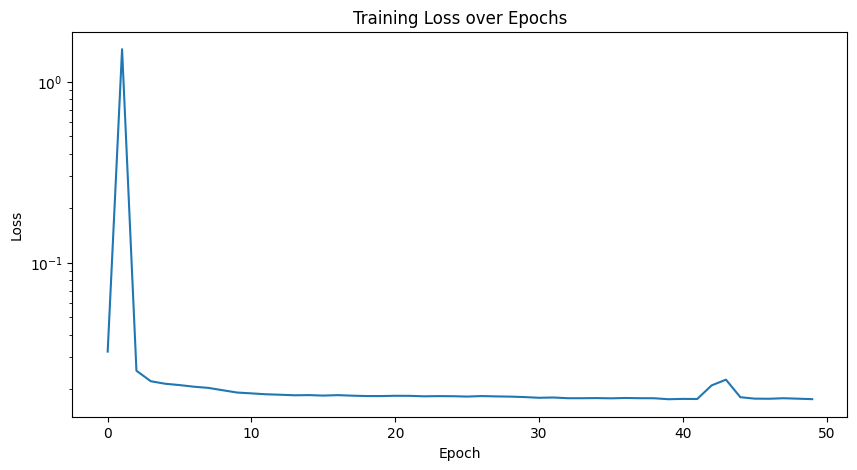

In [36]:
plt.figure(figsize=(10,5))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss over Epochs')
plt.yscale('log')
plt.show()

In [37]:
#calculer la rmse sur le test set
vae.eval()
test_losses = []
with torch.no_grad():
    for element in test_loader:
        element = element[0]
        pixel = element[:,:156]
        pixel = pixel.to(device).float()
        output, alpha_values = vae(pixel)
        #calculer la rmse
        loss = F.mse_loss(output, pixel, reduction='sum')
        test_losses.append(loss.item()/len(pixel))

print(f"Test set Loss: {np.mean(test_losses)}")

/var/folders/74/bcmygj1n3yj3djmv4kgqrkch0000gp/T/ipykernel_51447/1000933007.py:62: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x= torch.tensor(x)


Test set Loss: 8.842579244441188


In [38]:
def align_endmembers(E, E_h):
    """
    Aligne les endmembers appris E_h sur la vérité terrain E
    en testant toutes les permutations possibles.
    """
    n_sources = E.shape[0]
    best_perm = None
    best_error = float('inf')
    
    for perm in itertools.permutations(range(n_sources)):
        E_perm = E_h[list(perm), :]
        error = torch.norm(torch.tensor(E) - torch.tensor(E_perm)).item()
        if error < best_error:
            best_error = error
            best_perm = perm
    
    return E_h[list(best_perm), :], best_perm, best_error

In [39]:
emd1 = vae.decode(torch.tensor([1, 0, 0], dtype=torch.float, device=device).unsqueeze(0)).cpu().detach().numpy()
emd2 = vae.decode(torch.tensor([0, 1, 0], dtype=torch.float, device=device).unsqueeze(0)).cpu().detach().numpy()
emd3 = vae.decode(torch.tensor([0, 0, 1], dtype=torch.float, device=device).unsqueeze(0)).cpu().detach().numpy()

#normaliser
emd1 = emd1 / np.max(emd1)
emd2 = emd2 / np.max(emd2)
emd3 = emd3 / np.max(emd3)

In [40]:
E_h=np.vstack([emd1, emd2, emd3]).squeeze()

E_h_aligned, best_perm, best_error = align_endmembers(E_np, E_h)

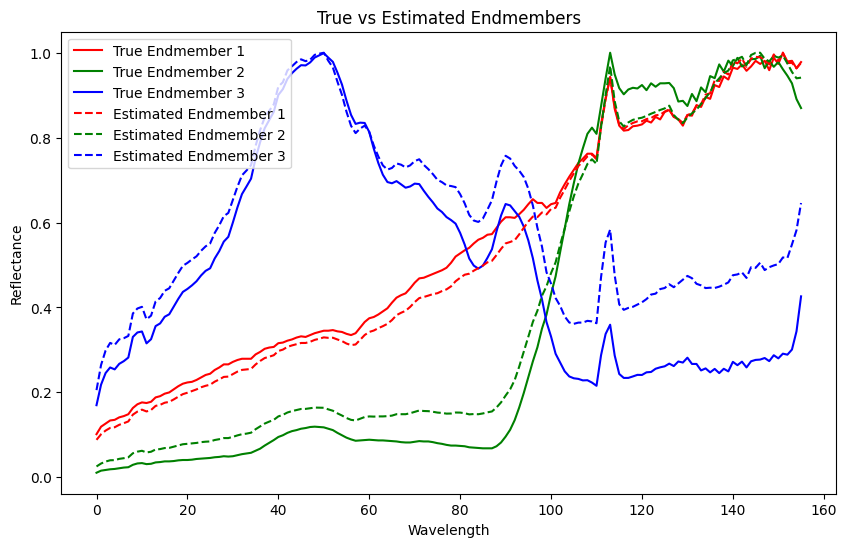

In [41]:
plt.figure(figsize=(10, 6))
plt.plot(range(156),E_np[0], label='True Endmember 1', color='r')
plt.plot(range(156),E_np[1], label='True Endmember 2', color='g')
plt.plot(range(156),E_np[2], label='True Endmember 3', color='b')
plt.plot(range(156),E_h_aligned[0], label='Estimated Endmember 1', linestyle='dashed', color='r')
plt.plot(range(156),E_h_aligned[1], label='Estimated Endmember 2', linestyle='dashed', color='g')
plt.plot(range(156),E_h_aligned[2], label='Estimated Endmember 3', linestyle='dashed', color='b')
plt.legend()
plt.xlabel('Wavelength')
plt.ylabel('Reflectance')
plt.title('True vs Estimated Endmembers')
plt.show()